# 04 — Pair-wise Baseline

Pairwise DNN (1128→256→256→256→1). Trained on **all N² pairs**. Loss = L1Loss (MAE).

**Input**: `data/processed/features/*.npz`, `data/processed/glyphs/*.npz`
**Output**: `data/processed/models/pairwise/best_model.pt`, `test_font_mae.csv`, `test_mae_flat.csv`


In [1]:
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
log = logging.getLogger("kern")

_cwd = Path.cwd().resolve()
if (_cwd / "pyproject.toml").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / "pyproject.toml").exists():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = _cwd
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FEATURE_DIR = DATA_PROCESSED / "features"
GLYPH_DIR = DATA_PROCESSED / "glyphs"
MODEL_DIR = DATA_PROCESSED / "models" / "pairwise"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

LATIN_52 = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
NUM_CLASSES = 52
FEATURE_DIM = 512
INPUT_DIM = FEATURE_DIM * 2 + NUM_CLASSES * 2  # 1128

# Training
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
MAX_EPOCHS = 100
EARLY_STOP_PATIENCE = 20
RANDOM_SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
log.info("Device: %s", DEVICE)
log.info("Root: %s", PROJECT_ROOT)

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

2026-07-24 10:37:52,139 | INFO | Device: cuda
2026-07-24 10:37:52,140 | INFO | Root: C:\Users\angel\OneDrive\Desktop\Kern


In [2]:
# Load catalog + features manifest
catalog = pd.read_csv(DATA_PROCESSED / "fonts_catalog.csv")
feat_manifest = pd.read_csv(DATA_PROCESSED / "features_manifest.csv")
ok_stems = set(feat_manifest[feat_manifest["status"] == "ok"]["stem"])
log.info("Fonts with features: %d", len(ok_stems))

# Preload features and pair_distances
unique_stems = sorted(ok_stems)
features_cache = {}
pair_dist_lookup = {}
glyph_names_cache = {}

for stem in tqdm(unique_stems, desc="Loading features + pair distances"):
    fz = np.load(FEATURE_DIR / f"{stem}.npz")
    features_cache[stem] = fz["features"]
    gz = np.load(GLYPH_DIR / f"{stem}.npz")
    glyph_names_cache[stem] = list(gz["glyph_names"])
    left, right, dists = gz["pair_left"], gz["pair_right"], gz["pair_distances"]
    lookup = {}
    for i in range(len(left)):
        lookup[(int(left[i]), int(right[i]))] = float(dists[i])
    pair_dist_lookup[stem] = lookup

total_mb = sum(a.nbytes for a in features_cache.values()) / 1e6
log.info("Features loaded: %.0f MB", total_mb)


stem_family = {}
for _, row in catalog[catalog["stem"].isin(ok_stems)].iterrows():
    stem_family[row["stem"]] = row["family"]

# stem_specs: (stem, family, N_glyphs, start_offset)
stem_specs = []
offset = 0
for stem in unique_stems:
    N = len(glyph_names_cache[stem])
    family = stem_family.get(stem, "unknown")
    stem_specs.append((stem, family, N, offset))
    offset += N * N

total_pairs = offset
log.info("Total pairs (N² per font): %d", total_pairs)



2026-07-24 10:37:52,187 | INFO | Fonts with features: 7263


Loading features + pair distances:   0%|          | 0/7263 [00:00<?, ?it/s]

2026-07-24 10:38:18,449 | INFO | Features loaded: 773 MB
2026-07-24 10:38:18,625 | INFO | Total pairs (N² per font): 19639152


In [3]:
# Split by font family
family_names = sorted(set(f for _, f, _, _ in stem_specs))
rng = np.random.default_rng(RANDOM_SEED)
rng.shuffle(family_names)

n = len(family_names)
n_train = int(n * 0.8)
n_val = int(n * 0.1)
train_families = set(family_names[:n_train])
val_families = set(family_names[n_train:n_train + n_val])
test_families = set(family_names[n_train + n_val:])

train_specs = [s for s in stem_specs if s[1] in train_families]
val_specs = [s for s in stem_specs if s[1] in val_families]
test_specs = [s for s in stem_specs if s[1] in test_families]

train_pairs = sum(s[2] * s[2] for s in train_specs)
val_pairs = sum(s[2] * s[2] for s in val_specs)
test_pairs = sum(s[2] * s[2] for s in test_specs)

log.info("Families: %d train / %d val / %d test", len(train_families), len(val_families), len(test_families))
log.info("Pairs: %d train / %d val / %d test", train_pairs, val_pairs, test_pairs)



2026-07-24 10:38:18,634 | INFO | Families: 1488 train / 186 val / 187 test
2026-07-24 10:38:18,635 | INFO | Pairs: 15569632 train / 1944176 val / 2125344 test


In [4]:
class PairwiseDataset(Dataset):
    def __init__(self, specs, features_cache, glyph_names_cache, pair_dist_lookup):
        self.stems = [s[0] for s in specs]
        self.Ns = [s[2] for s in specs]
        self.features = features_cache
        self.glyph_names = glyph_names_cache
        self.pair_dists = pair_dist_lookup
        self._char_to_idx = {c: i for i, c in enumerate(LATIN_52)}

        # Build cumulative offsets for THIS split (not pre-computed from full set)
        self._offsets = np.zeros(len(specs), dtype=np.int64)
        cum = 0
        for i, n in enumerate(self.Ns):
            self._offsets[i] = cum
            cum += n * n
        self._total = cum

    def __len__(self):
        return self._total

    def __getitem__(self, idx):
        stem_i = int(np.searchsorted(self._offsets, idx, side='right') - 1)
        stem = self.stems[stem_i]
        N = self.Ns[stem_i]
        local = idx - int(self._offsets[stem_i])
        li = local // N
        ri = local % N

        names = self.glyph_names[stem]
        g1, g2 = names[li], names[ri]

        feat = self.features[stem]
        f1 = torch.from_numpy(feat[li])
        f2 = torch.from_numpy(feat[ri])

        ci1 = self._char_to_idx.get(g1)
        ci2 = self._char_to_idx.get(g2)
        target = self.pair_dists[stem][(ci1, ci2)]

        oh1 = torch.zeros(NUM_CLASSES)
        oh2 = torch.zeros(NUM_CLASSES)
        if ci1 is not None:
            oh1[ci1] = 1.0
        if ci2 is not None:
            oh2[ci2] = 1.0

        x = torch.cat([f1, f2, oh1, oh2])
        return x, torch.tensor(target, dtype=torch.float32)


train_ds = PairwiseDataset(train_specs, features_cache, glyph_names_cache, pair_dist_lookup)
val_ds = PairwiseDataset(val_specs, features_cache, glyph_names_cache, pair_dist_lookup)
test_ds = PairwiseDataset(test_specs, features_cache, glyph_names_cache, pair_dist_lookup)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
log.info("DataLoaders ready — %d train pairs (lazy)", len(train_ds))



2026-07-24 10:38:18,645 | INFO | DataLoaders ready — 15569632 train pairs (lazy)


In [5]:
class PairwiseDNN(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


model = PairwiseDNN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
log.info("Model parameters: %d", n_params)
log.info("Input dim: %d", INPUT_DIM)

2026-07-24 10:38:19,982 | INFO | Model parameters: 355073
2026-07-24 10:38:19,983 | INFO | Input dim: 1128


In [6]:
CHECKPOINT_PATH = MODEL_DIR / "checkpoint.pt"
BEST_MODEL_PATH = MODEL_DIR / "best_model.pt"
HISTORY_PATH = MODEL_DIR / "training_history.csv"

def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total = 0.0, 0
    desc = "Train" if is_train else "Eval"
    for x, y in tqdm(loader, desc=desc, leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        if is_train:
            optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        if is_train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * len(y)
        total += len(y)
    return total_loss / total


# --- Resume or start fresh ---
start_epoch = 1
history = []
best_val_loss = float("inf")
patience_counter = 0

if CHECKPOINT_PATH.exists():
    ckpt = torch.load(CHECKPOINT_PATH, weights_only=False, map_location="cpu")
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    start_epoch = ckpt["epoch"] + 1
    best_val_loss = ckpt["best_val_loss"]
    patience_counter = ckpt["patience_counter"]
    history = ckpt.get("history", [])
    log.info("Resumed from epoch %d (best val_loss=%.4f)", ckpt["epoch"], best_val_loss)
else:
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    log.info("Starting fresh. LR=%.0e, batch=%d", LEARNING_RATE, BATCH_SIZE)

criterion = nn.L1Loss()  # MAE

for epoch in range(start_epoch, MAX_EPOCHS + 1):
    train_loss = run_epoch(train_loader, model, criterion, optimizer)
    val_loss = run_epoch(val_loader, model, criterion)
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
    log.info("Epoch %3d | train_loss=%.4f val_loss=%.4f", epoch, train_loss, val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        log.info("  → Saved best model")
    else:
        patience_counter += 1

    # Save checkpoint every epoch
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_loss": best_val_loss,
        "patience_counter": patience_counter,
        "history": history,
    }, CHECKPOINT_PATH)

    if patience_counter >= EARLY_STOP_PATIENCE:
        log.info("Early stopping at epoch %d", epoch)
        break

pd.DataFrame(history).to_csv(HISTORY_PATH, index=False)
log.info("Done. Training history saved")

if CHECKPOINT_PATH.exists():
    CHECKPOINT_PATH.unlink()
    log.info("Checkpoint removed (training complete)")

2026-07-24 10:38:21,708 | INFO | Starting fresh. LR=1e-04, batch=64


Train:   0%|          | 0/243276 [00:00<?, ?it/s]

Eval:   0%|          | 0/30378 [00:00<?, ?it/s]

2026-07-24 11:02:32,483 | INFO | Epoch   1 | train_loss=5.5925 val_loss=5.2673
2026-07-24 11:02:32,504 | INFO |   → Saved best model


Train:   0%|          | 0/243276 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/30378 [00:00<?, ?it/s]

2026-07-26 05:36:33,041 | INFO | Epoch  99 | train_loss=2.5757 val_loss=3.8452


Train:   0%|          | 0/243276 [00:00<?, ?it/s]

Eval:   0%|          | 0/30378 [00:00<?, ?it/s]

2026-07-26 06:03:01,695 | INFO | Epoch 100 | train_loss=2.5724 val_loss=3.8732
2026-07-26 06:03:01,878 | INFO | Done. Training history saved
2026-07-26 06:03:01,880 | INFO | Checkpoint removed (training complete)


In [8]:
# Load best model and evaluate on test set
model.load_state_dict(torch.load(BEST_MODEL_PATH, weights_only=True, map_location=DEVICE))
model.eval()

all_preds, all_targets, all_stems = [], [], []
with torch.no_grad():
    for idx in tqdm(range(len(test_ds)), desc="Testing"):
        x, y = test_ds[idx]
        x = x.unsqueeze(0).to(DEVICE)
        pred = model(x).item()
        all_preds.append(pred)
        all_targets.append(y.item())
        stem_i = int(np.searchsorted(test_ds._offsets, idx, side="right") - 1)
        all_stems.append(test_ds.stems[stem_i])

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
test_mae = np.abs(all_preds - all_targets).mean()
log.info("Test MAE: %.4f pixels", test_mae)

# Per-font MAE
test_df = pd.DataFrame({"stem": all_stems, "pred": all_preds, "target": all_targets})
font_mae = test_df.groupby("stem").apply(
    lambda g: np.abs(g["pred"] - g["target"]).mean()
).reset_index(name="mae")
font_mae.to_csv(MODEL_DIR / "test_font_mae.csv", index=False)
pd.DataFrame({"test_mae_flat": [test_mae]}).to_csv(MODEL_DIR / "test_mae_flat.csv", index=False)

log.info("Per-font MAE saved: %d fonts", len(font_mae))
log.info("  best font MAE:  %.4f", font_mae["mae"].min())
log.info("  worst font MAE: %.4f", font_mae["mae"].max())
log.info("  median font MAE: %.4f", font_mae["mae"].median())

Testing:   0%|          | 0/2125344 [00:00<?, ?it/s]

2026-07-26 07:09:50,702 | INFO | Test MAE: 3.8949 pixels
2026-07-26 07:09:51,041 | INFO | Per-font MAE saved: 786 fonts
2026-07-26 07:09:51,043 | INFO |   best font MAE:  0.5554
2026-07-26 07:09:51,043 | INFO |   worst font MAE: 30.5960
2026-07-26 07:09:51,045 | INFO |   median font MAE: 3.2479


In [9]:
print("=" * 60)
print("PAIR-WISE BASELINE — RESULTS")
print("=" * 60)

hist = pd.read_csv(HISTORY_PATH)
pw_flat = pd.read_csv(MODEL_DIR / "test_mae_flat.csv")["test_mae_flat"].values[0]
print(f"\n  Epochs trained:   {len(hist)}")
print(f"  Best val MAE:     {hist['val_loss'].min():.4f} px")
print(f"  Test MAE flat:    {pw_flat:.4f} px")
print(f"\n  Per-font MAE:")
print(f"    mean:           {font_mae['mae'].mean():.4f} px")
print(f"    median:         {font_mae['mae'].median():.4f} px")
print(f"    std:            {font_mae['mae'].std():.4f} px")
print(f"    min:            {font_mae['mae'].min():.4f} px")
print(f"    max:            {font_mae['mae'].max():.4f} px")
print(f"    fonts < 7 px:   {(font_mae['mae'] < 7).sum()} / {len(font_mae)}")

p25 = font_mae['mae'].quantile(0.25)
p75 = font_mae['mae'].quantile(0.75)
print(f"    25th pct:       {p25:.4f} px")
print(f"    75th pct:       {p75:.4f} px")
print("\n" + "=" * 60)


PAIR-WISE BASELINE — RESULTS

  Epochs trained:   100
  Best val MAE:     3.8063 px
  Test MAE flat:    3.8949 px

  Per-font MAE:
    mean:           3.8949 px
    median:         3.2479 px
    std:            2.8199 px
    min:            0.5554 px
    max:            30.5960 px
    fonts < 7 px:   700 / 786
    25th pct:       2.2122 px
    75th pct:       4.8545 px



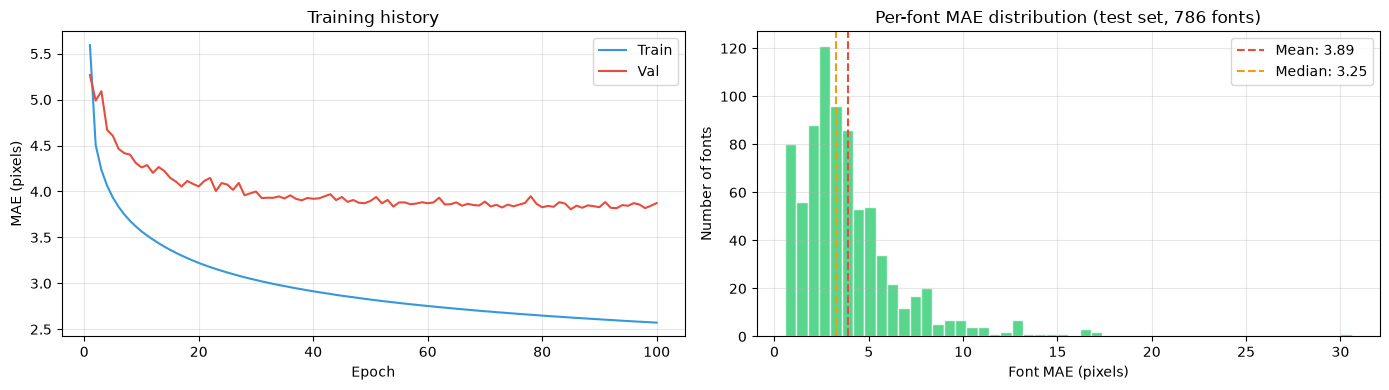

In [10]:
import matplotlib.pyplot as plt

hist = pd.read_csv(HISTORY_PATH)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Training curves
axes[0].plot(hist["epoch"], hist["train_loss"], label="Train", color="#3498db")
axes[0].plot(hist["epoch"], hist["val_loss"], label="Val", color="#e74c3c")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MAE (pixels)")
axes[0].set_title("Training history")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Per-font MAE distribution
axes[1].hist(font_mae["mae"], bins=50, color="#2ecc71", edgecolor="white", alpha=0.8)
axes[1].axvline(font_mae["mae"].mean(), color="#e74c3c", linestyle="--",
                label=f"Mean: {font_mae['mae'].mean():.2f}")
axes[1].axvline(font_mae["mae"].median(), color="#f39c12", linestyle="--",
                label=f"Median: {font_mae['mae'].median():.2f}")
axes[1].set_xlabel("Font MAE (pixels)")
axes[1].set_ylabel("Number of fonts")
axes[1].set_title(f"Per-font MAE distribution (test set, {len(font_mae)} fonts)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()